<a href="https://colab.research.google.com/github/akshaybhargav86/Customer-Shopping-Behavior-Analysis/blob/main/Customer%20Shopping%20Behavior%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
data = pd.read_excel('/content/row data.xlsx')

In [8]:
data.head(5)

,Date,Customer ID,Customer Age,Age Group,Customer Gender,Country,State,Product Category,Sub Category,Product,Frame Size,Order Quantity,Unit Cost,Unit Price,Cost,Revenue,Profit
0,26/11/2013,11019.0,19.0,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,NaN,8.0,45.0,120.0,360.0,950,590.0
1,26/11/2015,11019.0,19.0,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,NaN,8.0,45.0,120.0,360.0,950,590.0
2,23/03/2014,11039.0,49.0,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,NaN,23.0,45.0,120.0,1035.0,2401,1366.0
3,23/03/2016,11039.0,49.0,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,NaN,20.0,45.0,120.0,900.0,2088,1188.0
4,15/05/2014,11046.0,47.0,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,NaN,4.0,45.0,120.0,180.0,418,238.0


In [9]:
df = data.copy()

In [13]:
df.describe()

,Customer ID,Customer Age,Frame Size,Order Quantity,Unit Cost,Unit Price,Cost,Revenue,Profit
count,113036.000000,113036.000000,25982.000000,113036.000000,113037.000000,113036.000000,113036.000000,1.130370e+05,113036.000000
mean,19227.874341,35.919212,47.313063,11.901660,267.296366,452.938427,469.318695,1.508727e+03,285.051665
std,5307.581302,11.021936,6.860797,9.561857,549.833051,922.071219,884.866118,2.536256e+05,453.887443
min,11000.000000,17.000000,38.000000,1.000000,1.000000,2.000000,1.000000,2.000000e+00,-30.000000
25%,14611.000000,28.000000,42.000000,2.000000,2.000000,5.000000,28.000000,6.300000e+01,29.000000
50%,18664.000000,35.000000,46.000000,10.000000,9.000000,24.000000,108.000000,2.230000e+02,101.000000
75%,23475.000000,43.000000,52.000000,20.000000,42.000000,70.000000,432.000000,8.000000e+02,358.000000
max,29483.000000,87.000000,62.000000,32.000000,2171.000000,3578.000000,42978.000000,8.527101e+07,15096.000000


In [29]:
nulls = df.fillna(0)

In [31]:
nulls = df.isnull().sum()

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113037 entries, 0 to 113036
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Date              113037 non-null  object 
 1   Customer ID       113036 non-null  float64
 2   Customer Age      113036 non-null  float64
 3   Age Group         113036 non-null  object 
 4   Customer Gender   113036 non-null  object 
 5   Country           113036 non-null  object 
 6   State             113036 non-null  object 
 7   Product Category  113036 non-null  object 
 8   Sub Category      113036 non-null  object 
 9   Product           113036 non-null  object 
 10  Frame Size        25982 non-null   float64
 11  Order Quantity    113036 non-null  float64
 12  Unit Cost         113037 non-null  float64
 13  Unit Price        113036 non-null  float64
 14  Cost              113036 non-null  float64
 15  Revenue           113037 non-null  int64  
 16  Profit            11

In [35]:
cty_sales_cty = df.groupby('Country')['Revenue'].sum().sort_values(ascending= False)
cty_sales_cty

,Revenue
Country,
United States,27975547
Australia,21302059
United Kingdom,10646196
Germany,8978596
France,8432872
Canada,7935738


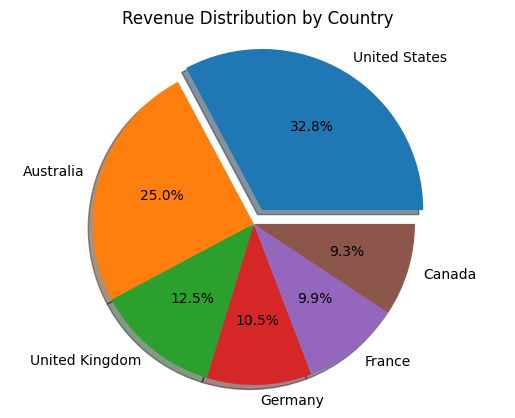

In [36]:
plt.pie(cty_sales_cty, labels=cty_sales_cty.index, autopct='%1.1f%%',explode=[0.1,0.0,0.0,0.0,0.0,0.0],shadow = True)
plt.title('Revenue Distribution by Country')
plt.axis('equal')
plt.show()

In [40]:
# Category performance analysis
cta = df.groupby('Product Category').agg({
    'Revenue': 'sum',
    'Profit': 'sum'
}).assign(Profit_Margin=lambda x: x['Profit'] / x['Revenue'])

Text(0.5, 1.0, 'Revenue by Product Category')

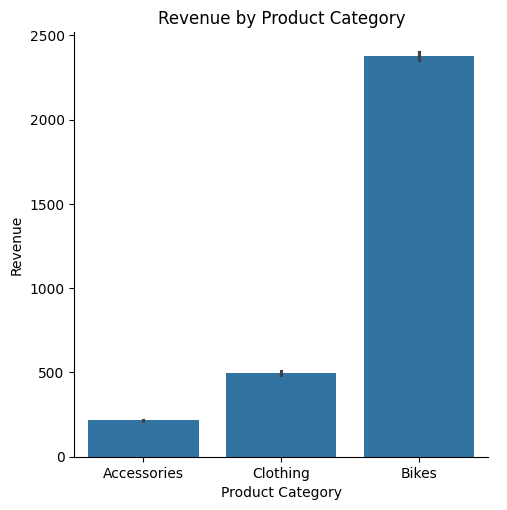

In [50]:
sns.catplot(x='Product Category', y='Revenue',data=df,kind='bar')
plt.title('Revenue by Product Category')

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113037 entries, 0 to 113036
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Date              113037 non-null  object 
 1   Customer ID       113036 non-null  float64
 2   Customer Age      113036 non-null  float64
 3   Age Group         113036 non-null  object 
 4   Customer Gender   113036 non-null  object 
 5   Country           113036 non-null  object 
 6   State             113036 non-null  object 
 7   Product Category  113036 non-null  object 
 8   Sub Category      113036 non-null  object 
 9   Product           113036 non-null  object 
 10  Frame Size        25982 non-null   float64
 11  Order Quantity    113036 non-null  float64
 12  Unit Cost         113037 non-null  float64
 13  Unit Price        113036 non-null  float64
 14  Cost              113036 non-null  float64
 15  Revenue           113037 non-null  int64  
 16  Profit            11

In [55]:
dT = df.drop(columns= ['Frame Size'] )

In [58]:
dT.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113037 entries, 0 to 113036
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Date              113037 non-null  object 
 1   Customer ID       113036 non-null  float64
 2   Customer Age      113036 non-null  float64
 3   Age Group         113036 non-null  object 
 4   Customer Gender   113036 non-null  object 
 5   Country           113036 non-null  object 
 6   State             113036 non-null  object 
 7   Product Category  113036 non-null  object 
 8   Sub Category      113036 non-null  object 
 9   Product           113036 non-null  object 
 10  Order Quantity    113036 non-null  float64
 11  Unit Cost         113037 non-null  float64
 12  Unit Price        113036 non-null  float64
 13  Cost              113036 non-null  float64
 14  Revenue           113037 non-null  int64  
 15  Profit            113036 non-null  float64
dtypes: float64(7), int64

In [ ]:
duplicates_c = df['Customer ID'].value_counts()
duplicates_c = duplicates_c[duplicates_c > 1]
duplicates_c
